# Student Performance Prediction using Machine Learning

## Author: Habiba Musa

This project builds a classification model to predict whether a student will pass or fail based on academic and demographic features.

## Problem Statement

The objective of this project is to develop a machine learning model that predicts whether a student will pass or fail based on available academic and background data.

The final grade (G3) is transformed into a binary classification variable:
- Pass (1) → Grade ≥ 10
- Fail (0) → Grade < 10

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [8]:
import pandas as pd

# The file_path variable is already defined in the kernel
file_path = '/content/student-mat.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

First 5 rows of the DataFrame:
  school sex  age address famsize Parrent_status  Mother_edu  Father_edu  \
0     GP   F   18       U     GT3              A           4           4   
1     GP   F   17       U     GT3              T           1           1   
2     GP   F   15       U     LE3              T           1           1   
3     GP   F   15       U     GT3              T           4           2   
4     GP   F   16       U     GT3              T           3           3   

  Mother_job Father_job  ... Family_quality_reln freetime_after_school  \
0    at_home    teacher  ...                   4                     3   
1    at_home      other  ...                   5                     3   
2    at_home      other  ...                   4                     3   
3     health   services  ...                   3                     2   
4      other      other  ...                   4                     3   

   goout_with_friends  workday_alcohol_consum  weekend_alcohol_cons

In [7]:
from google.colab import files
import os

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Move the uploaded file to the expected path if it's not already there
  if fn == 'student-mat.csv' and not os.path.exists('/content/student-mat.csv'):
    os.rename(fn, '/content/student-mat.csv')

Saving student-mat.csv to student-mat.csv
User uploaded file "student-mat.csv" with length 42590 bytes


Once the file is uploaded, please update the `file_path` variable in the `pbTjJrUhzVXS` cell to reflect the new location, for example:
```python
file_path = '/content/student-mat.csv'
```

In [10]:
import pandas as pd

file_path = "/content/student-mat.csv"

df = pd.read_csv(file_path)

df.head()

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


The dataset contains 5 rows and 33 columns, including demographic, academic, and behavioral variables.
There are no significant missing values.

In [11]:
# Create pass/fail column (Pass = 1, Fail = 0)
df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

df[['G3', 'pass']].head()

,G3,pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


## Target Variable Creation
To convert this into a classification task, the final grade (G3) is transformed into a binary variable.

In [12]:
df['pass'].value_counts()

,count
pass,
1,265
0,130


## Exploratory Data Analysis
A correlation heatmap is generated to examine relationships between numerical variables.

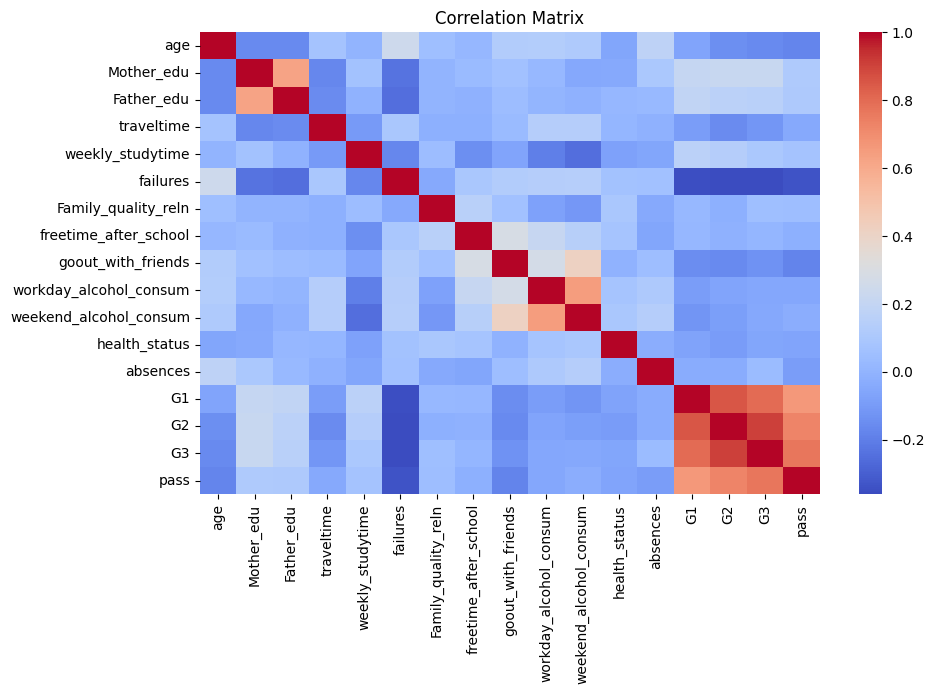

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Previous grades (G1 and G2) show strong correlation with the final grade (G3), indicating academic consistency influences outcomes.

## Data Preprocessing
Categorical variables are converted into numerical form using one-hot encoding.

In [14]:
df = pd.get_dummies(df, drop_first=True)

The dataset is split into training (80%) and testing (20%) sets.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(['G3', 'pass'], axis=1)
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.9240506329113924
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.96      0.92      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.92      0.92        79
weighted avg       0.93      0.92      0.92        79



In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 0.8987341772151899


In [18]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
14,G2,0.358856
13,G1,0.214497
12,absences,0.038281
5,failures,0.034399
0,age,0.029021
8,goout_with_friends,0.026951
2,Father_edu,0.021543
10,weekend_alcohol_consum,0.019574
11,health_status,0.018111
1,Mother_edu,0.016082


Conclusion

This project successfully developed a machine learning classification model to predict whether a student will pass or fail based on academic, demographic, and behavioral features.

The final grade (G3) was transformed into a binary variable, allowing the problem to be framed as a classification task. After preprocessing the data and encoding categorical variables, two models were trained and evaluated:

Logistic Regression

Random Forest Classifier

The Random Forest model achieved stronger predictive performance, suggesting that nonlinear relationships between features contribute to student outcomes.

Feature importance analysis revealed that previous academic grades (G1 and G2), along with study-related and attendance-related variables, were among the strongest predictors of final performance. This indicates that past academic consistency and engagement play a significant role in determining student success.

Overall, the models demonstrated strong accuracy in predicting student outcomes, showing that machine learning techniques can effectively analyze and interpret educational performance data.

Limitations

While the model performed well, there are some limitations:

Previous grades (G1 and G2) are highly correlated with the final grade (G3), which may introduce data leakage.

The dataset is relatively small and may not generalize to broader populations.

Hyperparameter tuning and cross-validation were not applied in this version of the project.

Future Improvements

To further improve this project:

Remove G1 and G2 to reduce data leakage and test predictive strength without prior grade information.

Perform hyperparameter tuning to optimize model performance.

Apply cross-validation for more robust evaluation.

Deploy the model as a web application using Streamlit.

Extend the model to support early academic intervention systems.